In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
tr = pd.read_csv('historical_data.csv')

print("Shape:", tr.shape)
print("Rows:", tr.shape[0])
print("Columns:", tr.shape[1])

Shape: (211224, 16)
Rows: 211224
Columns: 16


In [ ]:
# Block 2: Create date column from Timestamp IST 
tr['date'] = pd.to_datetime(tr['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date.astype(str)

print("Date column created successfully")
print("Sample dates:", tr['date'].head(5).tolist())
print("Date range:", tr['date'].min(), "to", tr['date'].max())

Date column created successfully
Sample dates: ['2024-12-02', '2024-12-02', '2024-12-02', '2024-12-02', '2024-12-02']
Date range: 2023-05-01 to 2025-05-01


In [4]:
# Block 3: Drop unnecessary columns
# Transaction Hash → blockchain receipt ID, no analytical value
# Order ID         → internal exchange ID, no analytical value
# Trade ID         → another internal ID, no analytical value
# Timestamp        → raw unix ms number, date column already covers it
# Timestamp IST    → original string, date column extracted from it
# Side             → just BUY/SELL, Direction column already tells more
# Size Tokens      → token count, Size USD is cleaner for comparison

cols_to_drop = ['Transaction Hash', 'Order ID', 'Trade ID',
                'Timestamp', 'Timestamp IST', 'Side', 'Size Tokens']

tr = tr.drop(columns=cols_to_drop)

print("Columns after drop:", tr.columns.tolist())
print("Shape after drop:", tr.shape)

Columns after drop: ['Account', 'Coin', 'Execution Price', 'Size USD', 'Start Position', 'Direction', 'Closed PnL', 'Crossed', 'Fee', 'date']
Shape after drop: (211224, 10)


In [5]:
#  Block 4: Column names and data types
print("Column Names:")
print(tr.columns.tolist())

print("\nData Types:")
print(tr.dtypes)

Column Names:
['Account', 'Coin', 'Execution Price', 'Size USD', 'Start Position', 'Direction', 'Closed PnL', 'Crossed', 'Fee', 'date']

Data Types:
Account                str
Coin                   str
Execution Price    float64
Size USD           float64
Start Position     float64
Direction              str
Closed PnL         float64
Crossed               bool
Fee                float64
date                   str
dtype: object


In [6]:
# Block 5: Null value check 
print("Null Values in Each Column:")
print(tr.isnull().sum())
print("\nTotal null values:", tr.isnull().sum().sum())

# Fill if any nulls found
# Numerical columns → fill with median
for col in ['Execution Price', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']:
    tr[col] = tr[col].fillna(tr[col].median())

# Categorical columns → fill with mode
for col in ['Account', 'Coin', 'Direction']:
    tr[col] = tr[col].fillna(tr[col].mode()[0])

print("\nNull values after fill:", tr.isnull().sum().sum())

Null Values in Each Column:
Account            0
Coin               0
Execution Price    0
Size USD           0
Start Position     0
Direction          0
Closed PnL         0
Crossed            0
Fee                0
date               0
dtype: int64

Total null values: 0

Null values after fill: 0


In [7]:
# Block 6: Duplicate check 
print("Duplicate rows:", tr.duplicated().sum())

tr = tr.drop_duplicates()
print("Shape after duplicate drop:", tr.shape)

Duplicate rows: 0
Shape after duplicate drop: (211224, 10)


In [8]:
# Block 7: Column type classification 
# NUMERICAL   : Execution Price, Size USD, Start Position, Closed PnL, Fee
# CATEGORICAL : Account, Coin, Direction, Crossed
# DATE        : date

print("Numerical columns  :", ['Execution Price', 'Size USD', 'Start Position', 'Closed PnL', 'Fee'])
print("Categorical columns:", ['Account', 'Coin', 'Direction', 'Crossed'])
print("Date column        :", ['date'])

Numerical columns  : ['Execution Price', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']
Categorical columns: ['Account', 'Coin', 'Direction', 'Crossed']
Date column        : ['date']


In [9]:
# lock 8: Numerical EDA — describe all numerical colum
num_cols = ['Execution Price', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']

for col in num_cols:
    print(f"\n── {col} ──")
    print(tr[col].describe())


── Execution Price ──
count    211224.000000
mean      11414.723350
std       29447.654868
min           0.000005
25%           4.854700
50%          18.280000
75%         101.580000
max      109004.000000
Name: Execution Price, dtype: float64

── Size USD ──
count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64

── Start Position ──
count    2.112240e+05
mean    -2.994625e+04
std      6.738074e+05
min     -1.433463e+07
25%     -3.762311e+02
50%      8.472793e+01
75%      9.337278e+03
max      3.050948e+07
Name: Start Position, dtype: float64

── Closed PnL ──
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

── Fee ──
count    211224.000000
mean          1.163967
std  

Execution Price → Skewness: 2.2994
Size USD → Skewness: 43.7774
Start Position → Skewness: -8.6845
Closed PnL → Skewness: 30.6994
Fee → Skewness: 35.5343


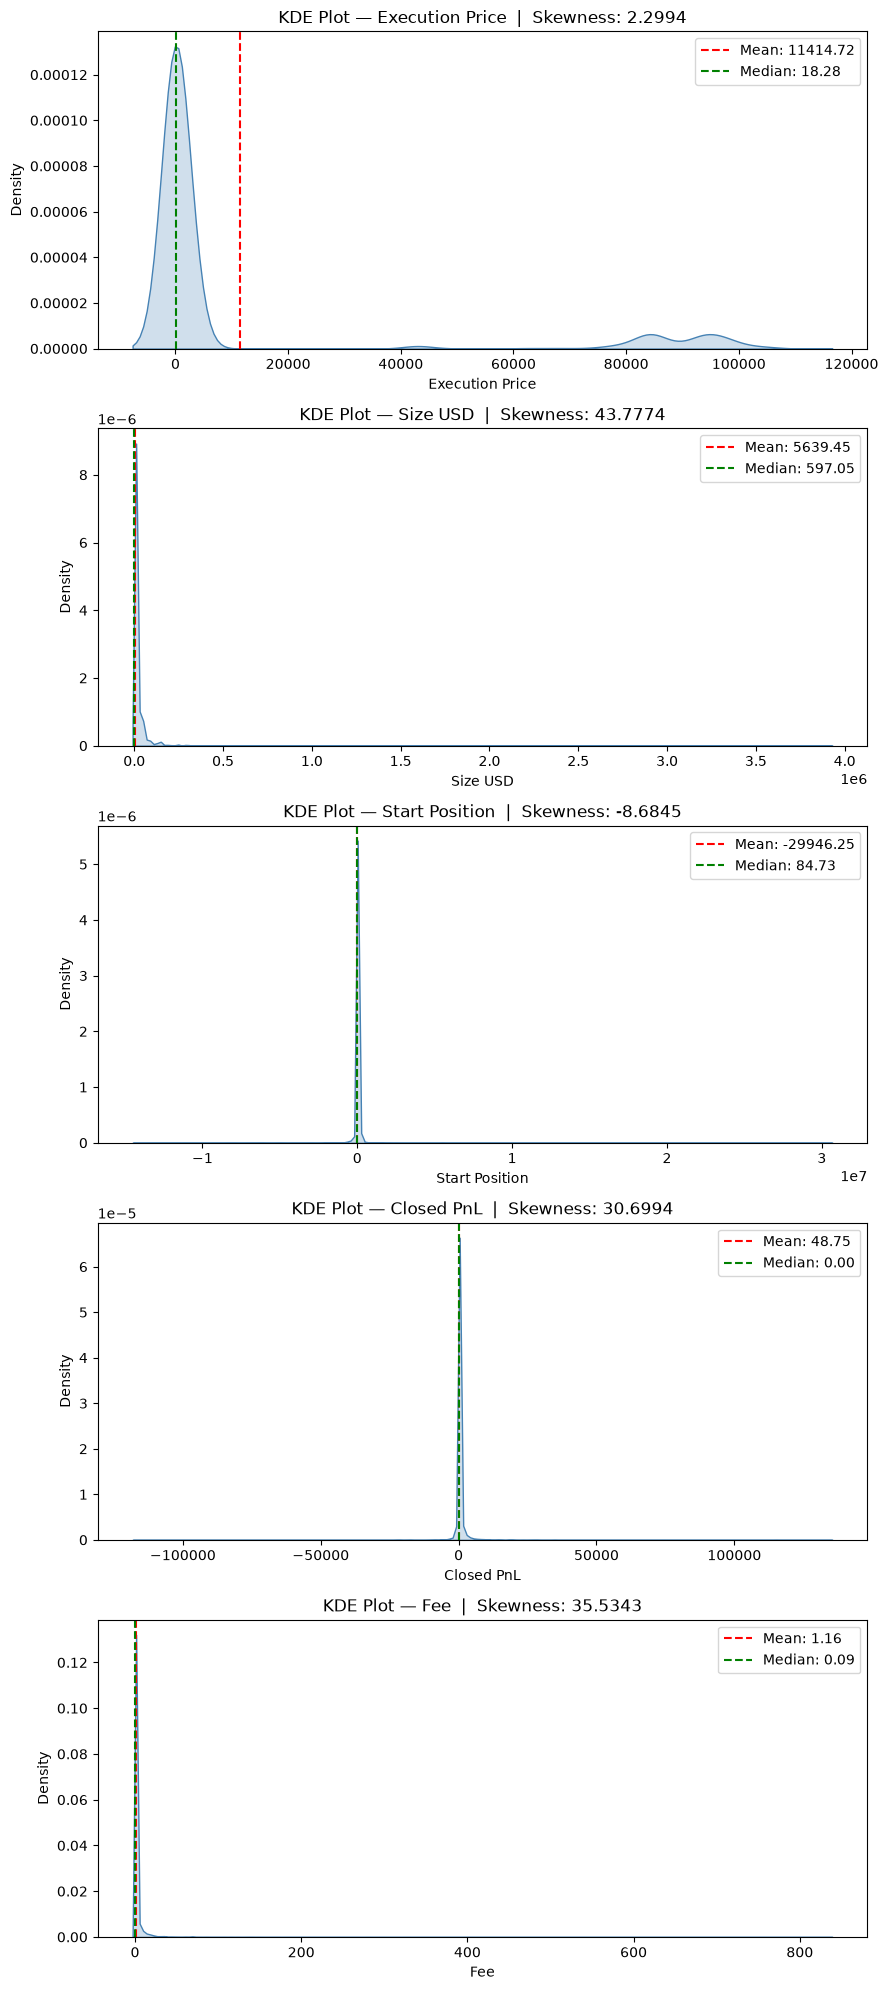

In [10]:
# Block 9: Numerical EDA — KDE plots + skewnes
num_cols = ['Execution Price', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']

fig, axes = plt.subplots(len(num_cols), 1, figsize=(9, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    skew = round(tr[col].skew(), 4)
    print(f"{col} → Skewness: {skew}")

    sns.kdeplot(tr[col], fill=True, color='steelblue', ax=axes[i])
    axes[i].set_title(f'KDE Plot — {col}  |  Skewness: {skew}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].axvline(tr[col].mean(),   color='red',   linestyle='--', label=f"Mean: {tr[col].mean():.2f}")
    axes[i].axvline(tr[col].median(), color='green', linestyle='--', label=f"Median: {tr[col].median():.2f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

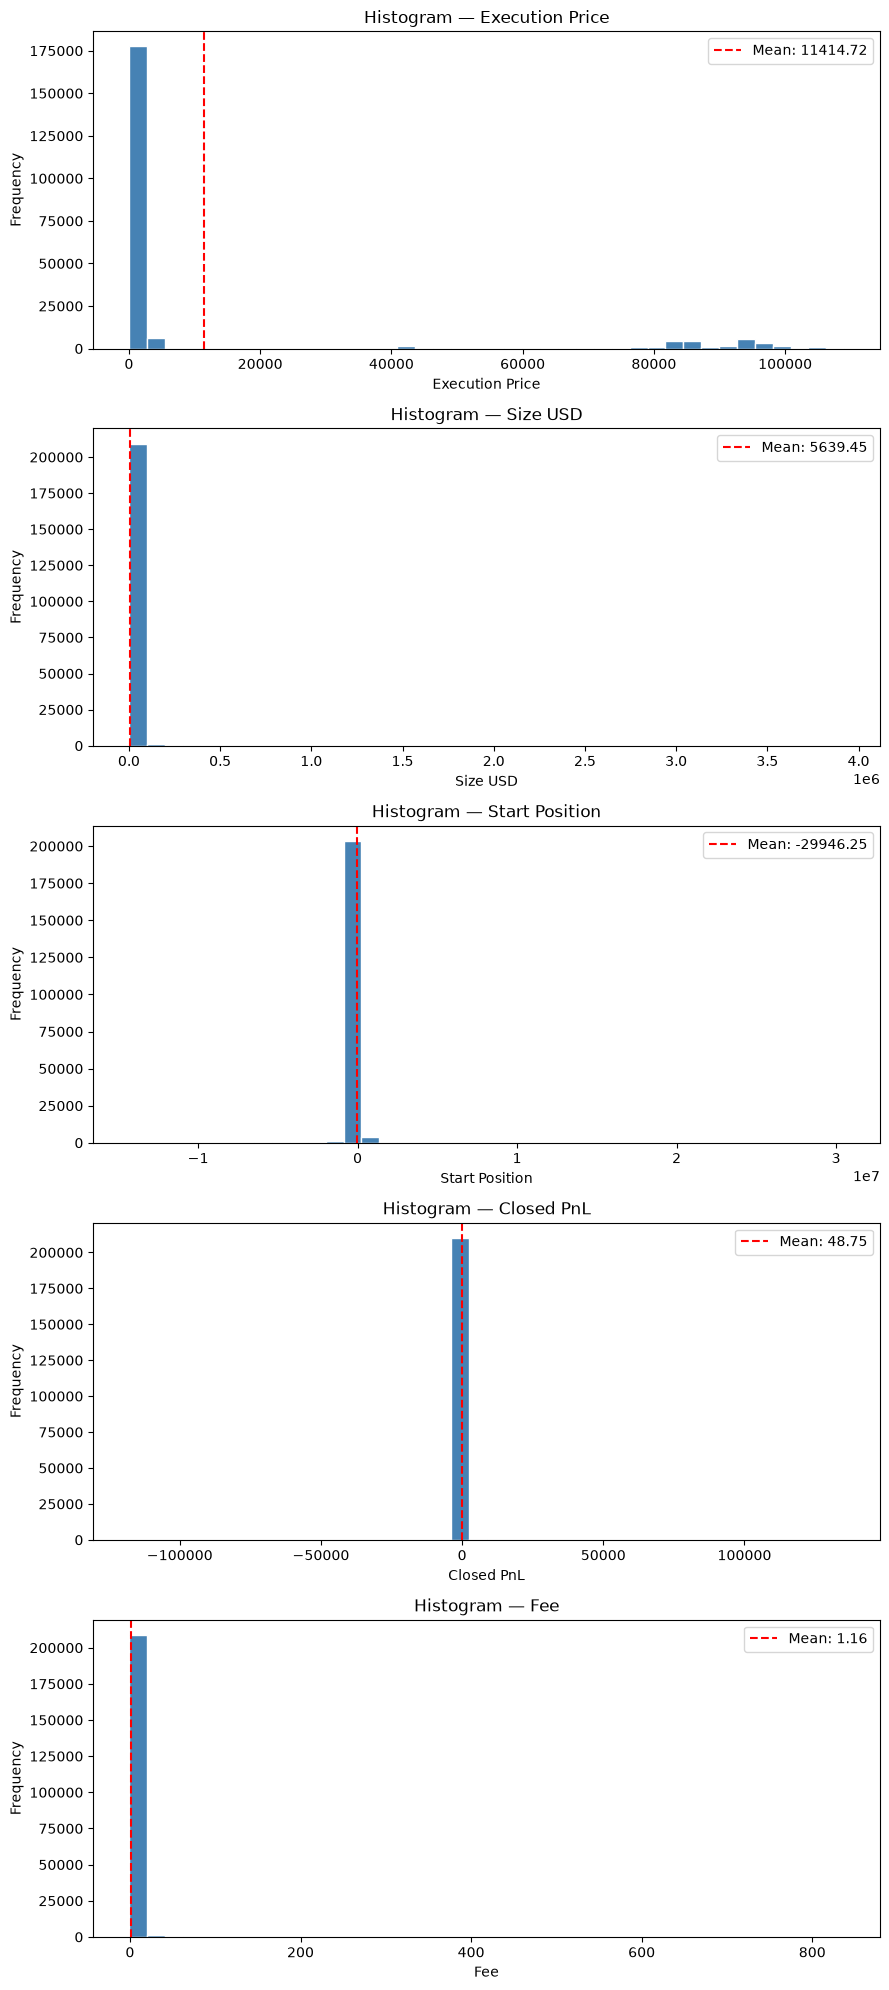

In [11]:
# Block 10: Numerical EDA — Histograms
fig, axes = plt.subplots(len(num_cols), 1, figsize=(9, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    axes[i].hist(tr[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Histogram — {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(tr[col].mean(), color='red', linestyle='--',
                    label=f"Mean: {tr[col].mean():.2f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

Execution Price → Outliers: 42187 (19.97%)
Size USD → Outliers: 32661 (15.46%)
Start Position → Outliers: 58346 (27.62%)
Closed PnL → Outliers: 48941 (23.17%)
Fee → Outliers: 30278 (14.33%)


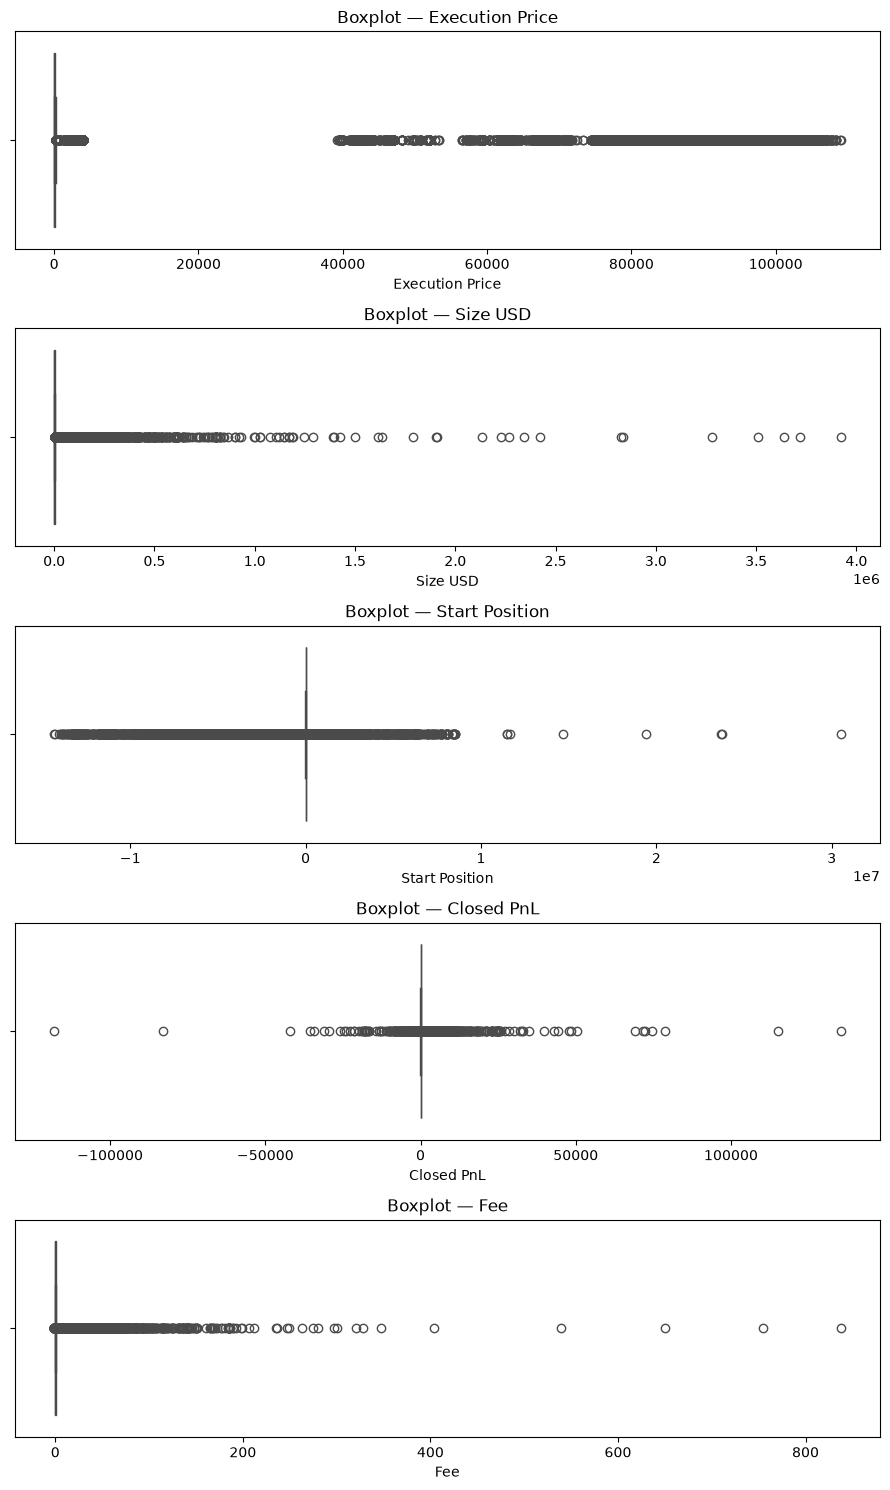

In [12]:
# ── Block 11: Numerical EDA — Boxplots + outlier count 
fig, axes = plt.subplots(len(num_cols), 1, figsize=(9, 3 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.boxplot(x=tr[col], color='steelblue', ax=axes[i])
    axes[i].set_title(f'Boxplot — {col}')
    axes[i].set_xlabel(col)

    Q1  = tr[col].quantile(0.25)
    Q3  = tr[col].quantile(0.75)
    IQR = Q3 - Q1
    out = tr[(tr[col] < Q1 - 1.5 * IQR) | (tr[col] > Q3 + 1.5 * IQR)]
    print(f"{col} → Outliers: {len(out)} ({round(len(out)/len(tr)*100, 2)}%)")

plt.tight_layout()
plt.show()

Unique Accounts: 32

Trades per Account:
                                            Count  Percentage
Account                                                      
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  40184       19.02
0xbaaaf6571ab7d571043ff1e313a9609a10637864  21192       10.03
0xa0feb3725a9335f49874d7cd8eaad6be45b27416  15605        7.39
0x8477e447846c758f5a675856001ea72298fd9cb5  14998        7.10
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  14733        6.98
0x28736f43f1e871e6aa8b1148d38d4994275d72c4  13311        6.30
0x513b8629fe877bb581bf244e326a047b249c4ff1  12236        5.79
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   9893        4.68
0x47add9a56df66b524d5e2c1993a43cde53b6ed85   8519        4.03
0x4f93fead39b70a1824f981a54d4e55b278e9f760   7584        3.59
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   7280        3.45
0xb899e522b5715391ae1d4f137653e7906c5e2115   4838        2.29
0x8170715b3b381dffb7062c0298972d4727a0a63b   4601        2.18
0x4acb90e786d897ecffb614dc822

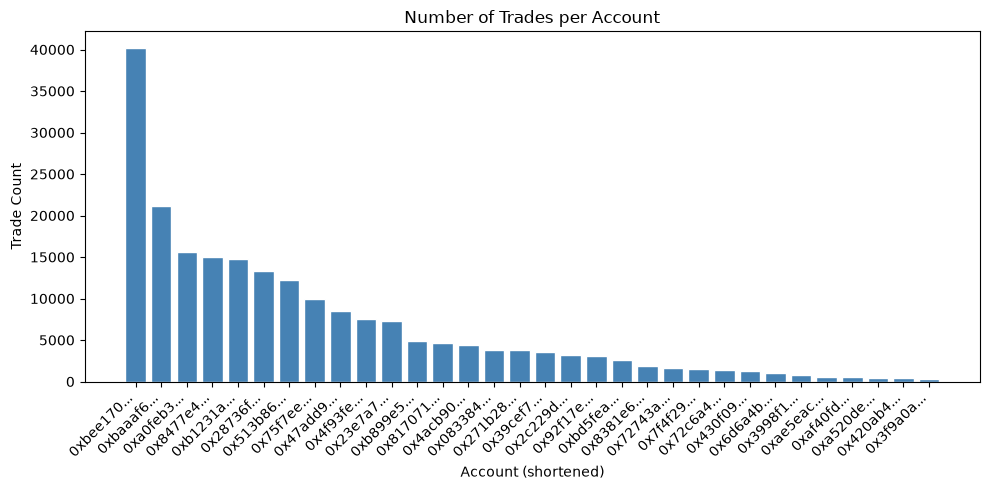

In [13]:
# ── Block 12: Categorical EDA — Account
print("Unique Accounts:", tr['Account'].nunique())

counts  = tr['Account'].value_counts()
percent = tr['Account'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage': percent.round(2)})
print("\nTrades per Account:")
print(summary)

# Bar chart — shorten wallet addresses for readability
plt.figure(figsize=(10, 5))
short_labels = [a[:8] + '...' for a in counts.index]
plt.bar(short_labels, counts.values, color='steelblue', edgecolor='white')
plt.title('Number of Trades per Account')
plt.xlabel('Account (shortened)')
plt.ylabel('Trade Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Unique Coins: 246

Top 10 Coins by Trade Count:
           Count  Percentage
Coin                        
HYPE       68005       32.20
@107       29992       14.20
BTC        26064       12.34
ETH        11158        5.28
SOL        10691        5.06
FARTCOIN    4650        2.20
MELANIA     4428        2.10
PURR/USDC   2774        1.31
WLD         1983        0.94
SUI         1979        0.94


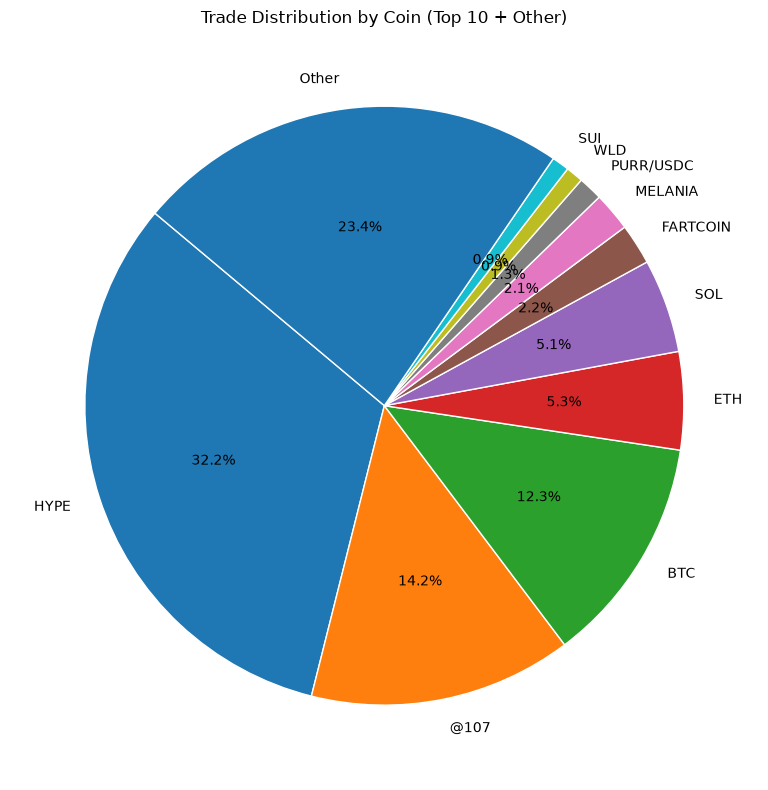

In [14]:
# ── Block 13: Categorical EDA — Coin 
print("Unique Coins:", tr['Coin'].nunique())

counts  = tr['Coin'].value_counts()
percent = tr['Coin'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage': percent.round(2)})
print("\nTop 10 Coins by Trade Count:")
print(summary.head(10))

# Pie chart — top 10 coins, rest grouped as Other
top10  = counts.head(10)
other  = counts.iloc[10:].sum()
pie_data   = pd.concat([top10, pd.Series({'Other': other})])

plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
        startangle=140, wedgeprops={'edgecolor': 'white'})
plt.title('Trade Distribution by Coin (Top 10 + Other)')
plt.tight_layout()
plt.show()

Unique Direction values: 12

Direction Value Counts:
                           Count  Percentage
Direction                                   
Open Long                  49895       23.62
Close Long                 48678       23.05
Open Short                 39741       18.81
Close Short                36013       17.05
Sell                       19902        9.42
Buy                        16716        7.91
Spot Dust Conversion         142        0.07
Short > Long                  70        0.03
Long > Short                  57        0.03
Auto-Deleveraging              8        0.00
Liquidated Isolated Short      1        0.00
Settlement                     1        0.00


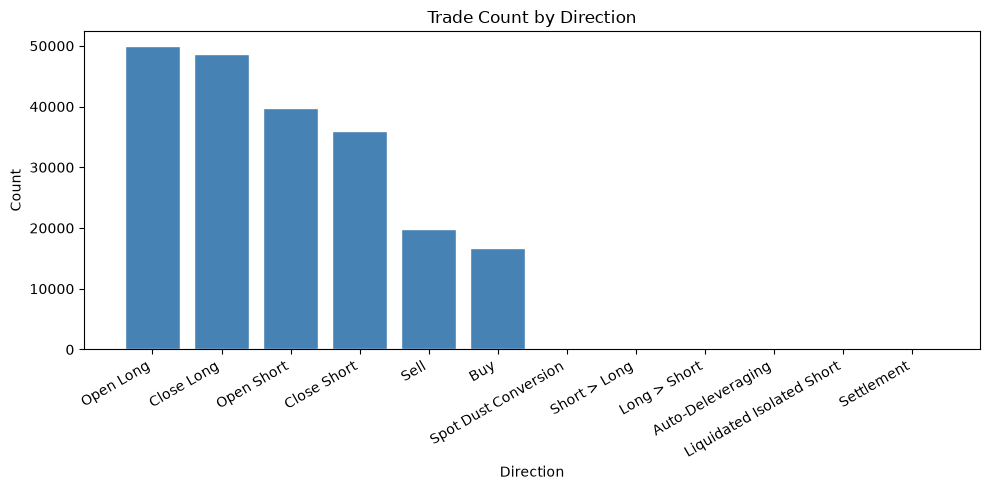

In [15]:
# ── Block 14: Categorical EDA — Direction 
print("Unique Direction values:", tr['Direction'].nunique())

counts  = tr['Direction'].value_counts()
percent = tr['Direction'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage': percent.round(2)})
print("\nDirection Value Counts:")
print(summary)

# Bar chart
plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
plt.title('Trade Count by Direction')
plt.xlabel('Direction')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Crossed Value Counts:
          Count  Percentage
Crossed                    
True     128403       60.79
False     82821       39.21


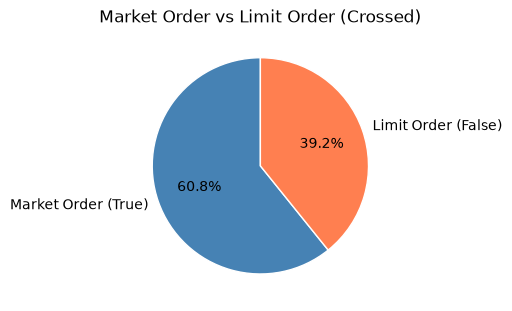

In [16]:
# ── Block 15: Categorical EDA — Crossed 
print("Crossed Value Counts:")
counts  = tr['Crossed'].value_counts()
percent = tr['Crossed'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage': percent.round(2)})
print(summary)
# True  = market order (filled immediately)
# False = limit order (waited in order book)

plt.figure(figsize=(5, 5))
plt.pie(counts, labels=['Market Order (True)', 'Limit Order (False)'],
        autopct='%1.1f%%', colors=['steelblue', 'coral'],
        wedgeprops={'edgecolor': 'white'}, startangle=90)
plt.title('Market Order vs Limit Order (Crossed)')
plt.tight_layout()
plt.show()

# ── Notebook 2 Conclusions — Historical Trader Data ──────────────────────────

'''
DATASET OVERVIEW
- Total records: 211,224 rows and 10 columns after dropping 7 unnecessary columns
- 7 columns dropped: Transaction Hash, Order ID, Trade ID, Timestamp,
  Timestamp IST, Side, Size Tokens — all were either IDs with no analytical
  value or duplicates of information already present in other columns
- date column created from Timestamp IST for merging later
- Data covers trades from 2023-05-01 to 2025-05-01 — around 2 years
- 32 unique traders across 246 unique coins

DATA QUALITY
- No null values found in any column — dataset is complete
- No duplicate rows found — every trade record is unique
- Data types are clean — no fixes needed

NUMERICAL COLUMN — Execution Price
- Ranges from 0 to 109,004 — covers tiny meme coins all the way up to BTC
- Mean is 11,414 but median is only 18.28 — huge gap shows most trades
  happen on low-priced coins, BTC trades pull the mean up heavily
- Skewness of 2.30 — moderately right skewed
- 19.97% outliers — expected given the massive price difference between
  BTC and small altcoins, not data errors

NUMERICAL COLUMN — Size USD
- Mean trade size is $5,639 but median is only $597 — again a big gap
- A few very large trades (max $3.9 million) are pulling the mean up
- Skewness of 43.78 — extremely right skewed, most trades are small
- 15.46% outliers — driven by a handful of very large position trades

NUMERICAL COLUMN — Start Position
- This column has both positive and negative values (min -14.3M, max 30.5M)
- Negative values mean the trader was holding a short position before the trade
- Skewness of -8.68 — left skewed, unusual compared to other columns
- 27.62% flagged as outliers — highest among all columns, driven by a few
  traders holding extremely large positions

NUMERICAL COLUMN — Closed PnL  ← most important column
- 50.57% of rows have Closed PnL = 0 — these are opening trades where
  no position was closed yet, so no profit or loss was realised
- Only 104,408 rows have actual PnL — these are the closed trades
- Max profit on a single trade: $135,329 | Max loss: -$117,990
- Mean PnL of $48.75 looks positive but is misleading due to the zeros
- Skewness of 30.70 — extremely skewed, a few big wins/losses dominate
- In Notebook 3 we will filter only non-zero PnL rows for analysis

NUMERICAL COLUMN — Fee
- Average fee is $1.16 per trade — quite small relative to trade size
- Max fee of $837 on a single trade — that was a very large trade
- Negative fees exist (min -1.18) — these are liquidity rebates where
  the exchange paid the trader for providing liquidity
- Skewness of 35.53 — extremely right skewed, most fees are tiny

CATEGORICAL COLUMN — Account
- Only 32 unique traders in this entire dataset
- Top trader (0xbee1...) made 40,184 trades — most active by far
- 2nd place: 21,192 trades | 3rd place: 15,605 trades
- Trading activity is heavily concentrated in a few accounts

CATEGORICAL COLUMN — Coin
- 246 unique coins traded
- HYPE dominates with 68,005 trades (32.2% of all trades)
- Top 5: HYPE, @107, BTC, ETH, SOL — these 5 cover majority of activity
- Long tail of 241 other coins with very few trades each

CATEGORICAL COLUMN — Direction
- Open Long (49,895) and Close Long (48,678) are the most common —
  traders lean bullish overall
- Open Short (39,741) and Close Short (36,013) show decent short activity too
- Buy (16,716) and Sell (19,902) are spot trades
- Edge cases: Spot Dust Conversion (142), Short>Long (70), Long>Short (57),
  Auto-Deleveraging (8), Liquidated Isolated Short (1), Settlement (1)
- These edge cases are less than 0.15% of total trades — minor but worth noting

CATEGORICAL COLUMN — Crossed
- 60.79% trades are market orders (Crossed = True) — filled immediately
- 39.21% are limit orders (Crossed = False) — waited in the order book
- Traders slightly prefer market orders, suggesting urgency in execution

KEY TAKEAWAY
- Dataset is clean and ready to merge
- Most important finding: half the rows have zero Closed PnL — these must be
  filtered out before any profit/loss analysis in Notebook 3
- Trading is highly concentrated — few traders, few coins dominate the activity
- All numerical columns are heavily right skewed — a few large trades/positions
  dominate the averages
'''
